C:\Users\Student\AppData\Local\Temp\ipykernel_26004\3345867525.py:40: RuntimeWarning: invalid value encountered in scalar divide
  frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))


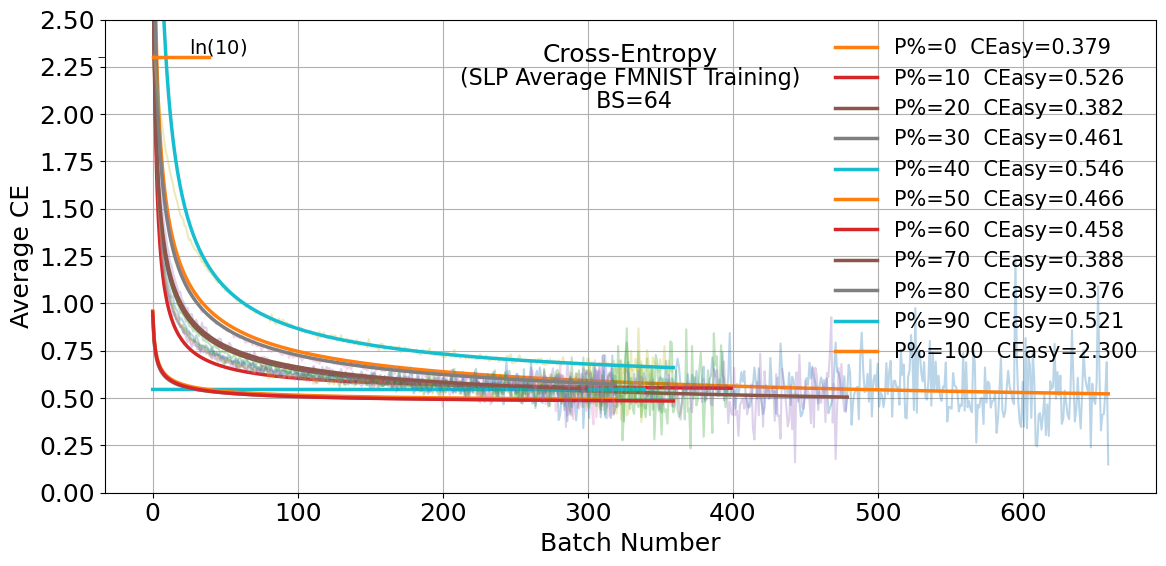

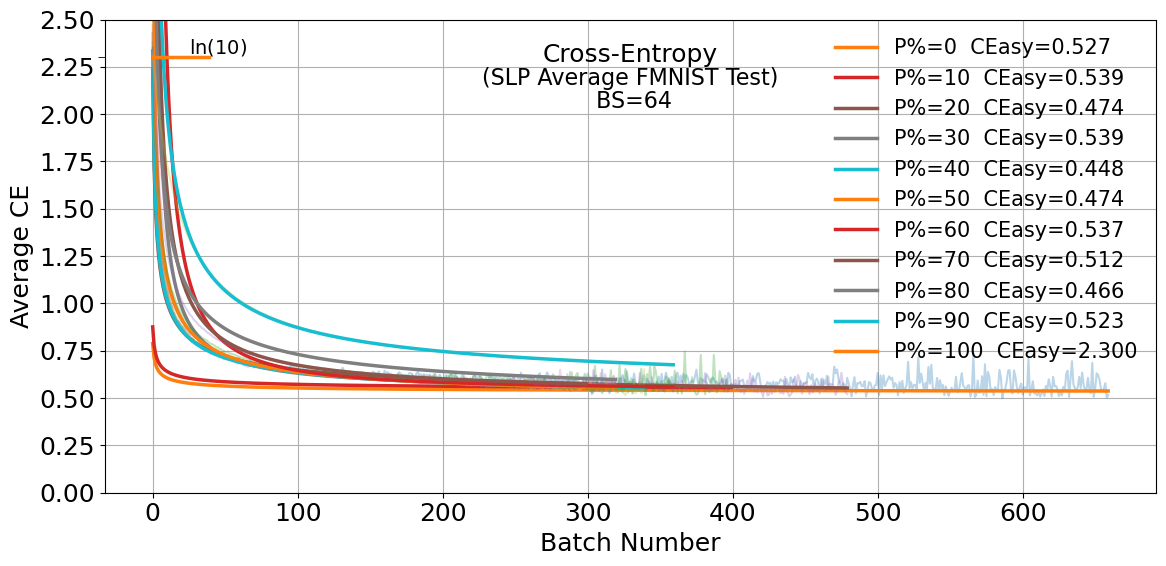

[DONE] Asymptotes saved for Batch Size 64


C:\Users\Student\AppData\Local\Temp\ipykernel_26004\3345867525.py:40: RuntimeWarning: invalid value encountered in scalar divide
  frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))


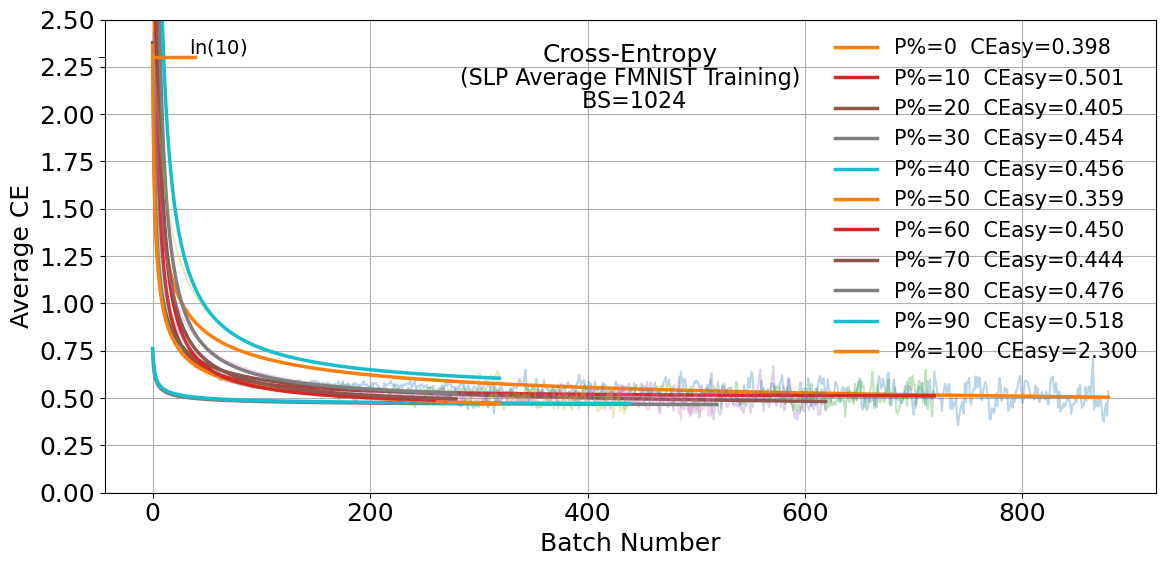

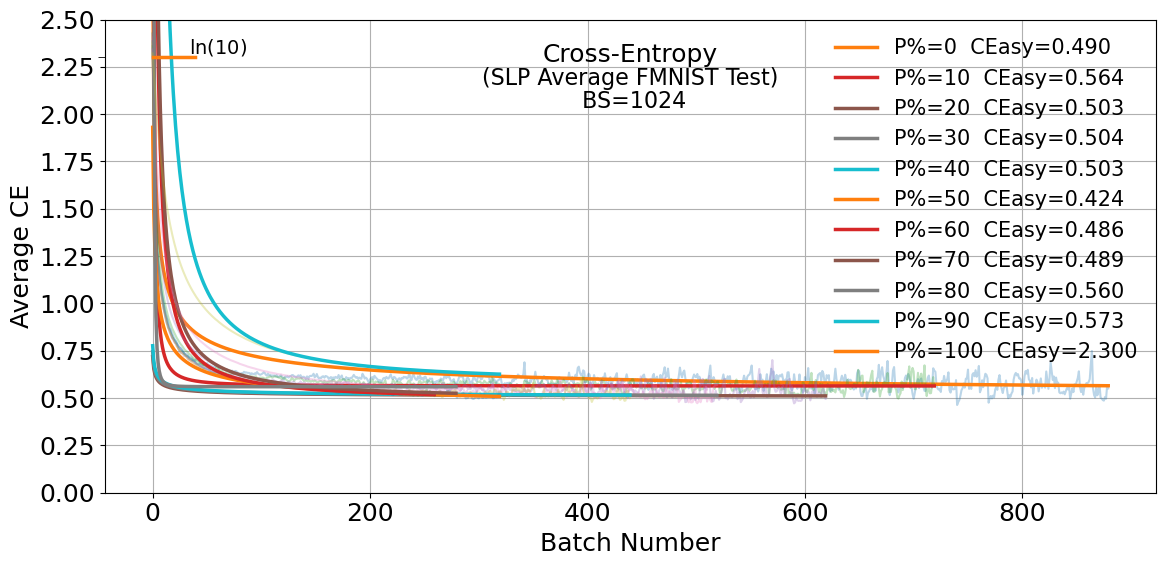

[DONE] Asymptotes saved for Batch Size 1024


C:\Users\Student\AppData\Local\Temp\ipykernel_26004\3345867525.py:40: RuntimeWarning: invalid value encountered in scalar divide
  frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))


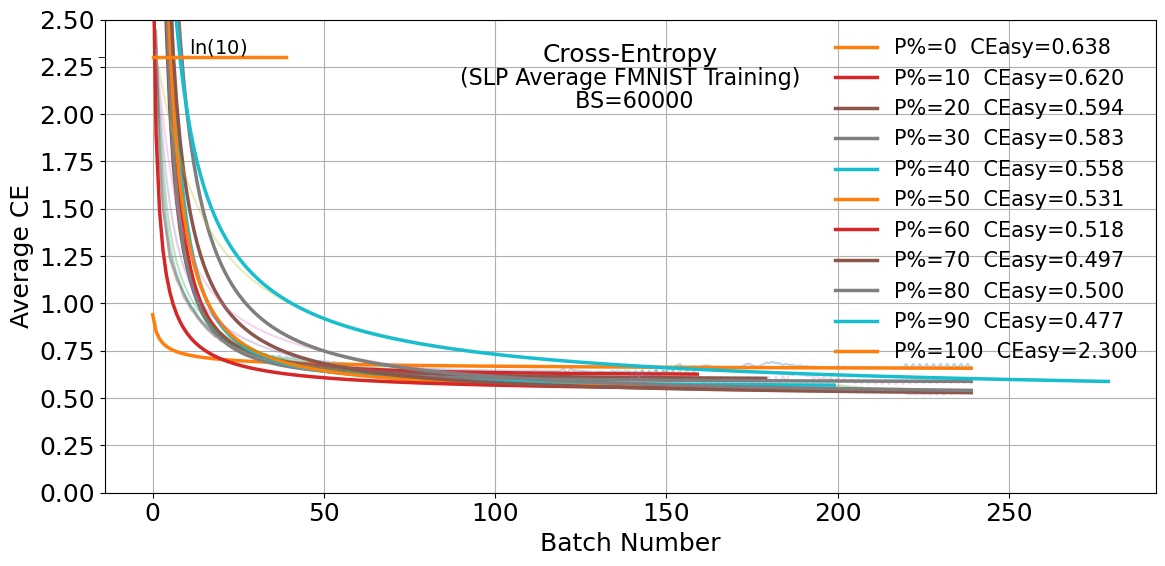

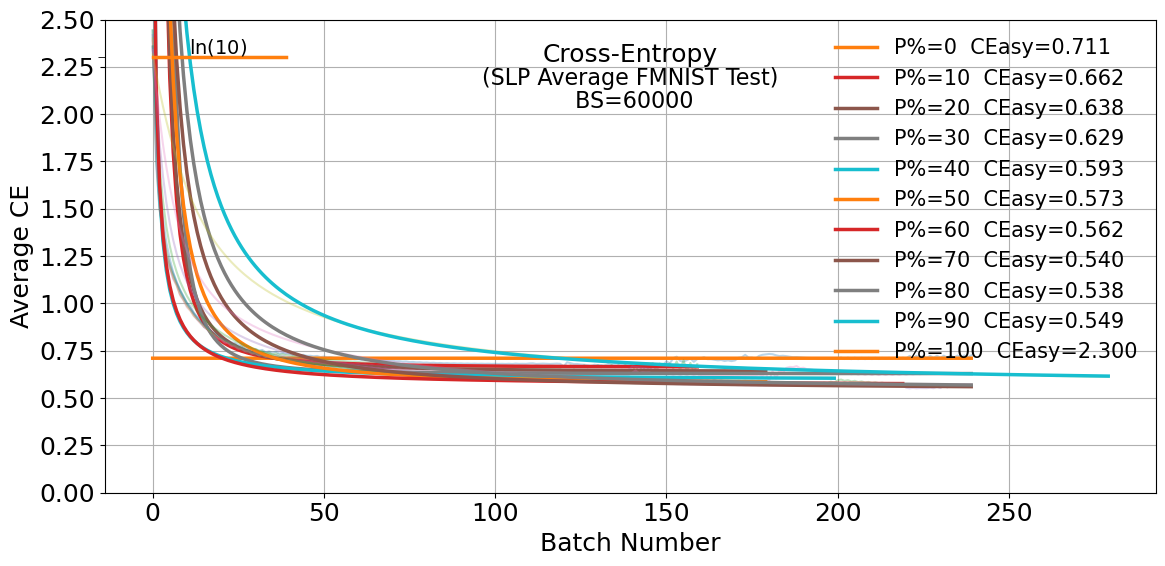

[DONE] Asymptotes saved for Batch Size 60000


In [2]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from lmfit import minimize, Parameters

# =========================
# CONFIG
# =========================
BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL"

BATCH_DIR_TEMPLATE = "p-percentage_{:.1f}\\batch_size_{}"
FILE_PATTERN = "slp_{:.1f}_{}_run_*"

BATCH_SIZES = [64, 1024, 60000]

LN10 = np.log(10)

# =========================
# FIT PARAMETERS
# =========================
A_MIN, A_MAX = 0.1, 2.3
B_MIN, B_MAX = 0, 1000
N_MIN, N_MAX = 0.5, 3.0

# =========================
# FITTING FUNCTIONS
# =========================
def initialize_guesses(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]

    A0 = np.percentile(y, 5)
    B0 = np.percentile(y, 95) - A0
    n0 = 0.5

    if len(x) > 10:
        frac = max(1e-6, (y[0] - y[-1]) / (y[0] - A0))
        if frac > 0:
            n0 = max(0.3, min(1.5, -np.log(frac)))

    return A0, n0, B0

def model(params, x):
    vals = params.valuesdict()
    A, B, n = vals['A'], vals['B'], vals['n']
    return A + B / ((x + 1)**n)

def residual(params, x, data):
    weight = x**2
    return weight * (model(params, x) - data)

def fit_curve(x, y):
    mask = ~np.isnan(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) < 10:
        return None

    A0, n0, B0 = initialize_guesses(x_fit, y_fit)

    params = Parameters()
    params.add('A', value=A0, min=A_MIN, max=A_MAX)
    params.add('B', value=B0, min=B_MIN, max=B_MAX)
    params.add('n', value=n0, min=N_MIN, max=N_MAX)

    try:
        out = minimize(residual, params, args=(x_fit, y_fit))
        return out
    except:
        return None

# =========================
# STYLE
# =========================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15
})

# =========================
# MAIN LOOP
# =========================
os.makedirs("Asymptote_Data", exist_ok=True)

for bs in BATCH_SIZES:

    all_avg_dfs = {}

    # -------------------------
    # LOAD + AVERAGE
    # -------------------------
    for p in [round(x * 0.1, 1) for x in range(0, 11)]:

        folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(p, bs))
        pattern = FILE_PATTERN.format(p, bs)
        files = glob.glob(os.path.join(folder, pattern))

        if not files:
            print(f"[WARNING] No files found for pruning {p} and batch size {bs}")
            continue

        dfs = []
        for f in files:
            df = pd.read_csv(f, sep=r"\s+")
            df.columns = df.columns.str.strip()

            df["CE_Train"] = pd.to_numeric(df["CE_Train"], errors="coerce")
            df["CE_TEST"] = pd.to_numeric(df["CE_TEST"], errors="coerce")
            df["Accuracy(%)"] = pd.to_numeric(df["Accuracy(%)"], errors="coerce")

            dfs.append(df)

        all_runs = pd.concat(dfs, ignore_index=True)

        avg_df = all_runs.groupby("Batch_Number", as_index=False).agg(
            Avg_CE_Train=("CE_Train", "mean"),
            Avg_CE_Test=("CE_TEST", "mean"),
            Avg_Accuracy=("Accuracy(%)", "mean"),
            Num_Runs=("CE_TEST", "count")
        )

        out_csv = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")
        avg_df.to_csv(out_csv, index=False)

        all_avg_dfs[p] = avg_df

    # -------------------------
    # CE TRAIN PLOT + FIT
    # -------------------------
    plt.figure(figsize=(12, 6))

    for p, avg_df in all_avg_dfs.items():

        x = avg_df["Batch_Number"].to_numpy(dtype=float)
        y = avg_df["Avg_CE_Train"].to_numpy(dtype=float)

        plt.plot(x, y, alpha=0.3)

        fit = fit_curve(x, y)

        if fit is not None:
            y_fit = model(fit.params, x)
            A_val = fit.params['A'].value

            plt.plot(
                x, y_fit,
                linewidth=2.5,
                label=f"P%={int(p*100)}  CEasy={A_val:.3f}"
            )
        else:
            plt.plot(x, y, label=f"P%={int(p*100)}")

    plt.xlabel("Batch Number")
    plt.ylabel("Average CE")
    plt.ylim(0, 2.5)
    plt.yticks([x * 0.25 for x in range(0, 11)])

    plt.text(0.08, LN10 + 0.05, r"$\ln(10)$",
             transform=plt.gca().get_yaxis_transform(),
             fontsize=14, va="center", ha="left")

    plt.gca().yaxis.set_minor_locator(plt.FixedLocator([LN10]))
    plt.tick_params(axis='y', which='minor', length=5)

    plt.text(0.50, 0.95, "Cross-Entropy",
             transform=plt.gca().transAxes, va="top", ha="center")

    plt.text(0.50, 0.90,
             f"(SLP Average FMNIST Training)",
             transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)
    plt.text(0.50, 0.85,f" BS={bs}",
         transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)

    plt.legend(frameon=False, loc='upper right')
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(f"CE_Train_Fit_BS_{bs}.png", dpi=300)
    plt.show()

    # -------------------------
    # CE TEST PLOT + FIT
    # -------------------------
    plt.figure(figsize=(12, 6))

    for p, avg_df in all_avg_dfs.items():

        x = avg_df["Batch_Number"].to_numpy(dtype=float)
        y = avg_df["Avg_CE_Test"].to_numpy(dtype=float)

        plt.plot(x, y, alpha=0.3)

        fit = fit_curve(x, y)

        if fit is not None:
            y_fit = model(fit.params, x)
            A_val = fit.params['A'].value

            plt.plot(
                x, y_fit,
                linewidth=2.5,
                label=f"P%={int(p*100)}  CEasy={A_val:.3f}"
            )
        else:
            plt.plot(x, y, label=f"P%={int(p*100)}")

    plt.xlabel("Batch Number")
    plt.ylabel("Average CE")
    plt.ylim(0, 2.5)
    plt.yticks([x * 0.25 for x in range(0, 11)])

    plt.text(0.08, LN10 + 0.05, r"$\ln(10)$",
             transform=plt.gca().get_yaxis_transform(),
             fontsize=14, va="center", ha="left")
    plt.gca().yaxis.set_minor_locator(plt.FixedLocator([LN10]))
    plt.tick_params(axis='y', which='minor', length=5)

    plt.text(0.50, 0.95, "Cross-Entropy",
             transform=plt.gca().transAxes, va="top", ha="center")

    plt.text(0.50, 0.90,
             f"(SLP Average FMNIST Test)",
             transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)
    plt.text(0.50, 0.85,f" BS={bs}",
             transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)

    plt.legend(frameon=False, loc='upper right')
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(f"CE_Test_Fit_BS_{bs}.png", dpi=300)
    plt.show()

    # -------------------------
    # SAVE ASYMPTOTES
    # -------------------------
    asymptote_rows = []
    for p, avg_df in all_avg_dfs.items():
        # Train
        x_train = avg_df["Batch_Number"].to_numpy(dtype=float)
        y_train = avg_df["Avg_CE_Train"].to_numpy(dtype=float)
        fit_train = fit_curve(x_train, y_train)
        A_train = fit_train.params['A'].value if fit_train is not None else np.nan

        # Test
        x_test = avg_df["Batch_Number"].to_numpy(dtype=float)
        y_test = avg_df["Avg_CE_Test"].to_numpy(dtype=float)
        fit_test = fit_curve(x_test, y_test)
        A_test = fit_test.params['A'].value if fit_test is not None else np.nan

        asymptote_rows.append([int(p*100), bs, A_train, A_test])

    df_asymptotes = pd.DataFrame(asymptote_rows, columns=[
        "Pruning_Percentage", "Batch_Size", "CE_Train_Asymptote", "CE_Test_Asymptote"
    ])

    df_asymptotes.to_csv(f"Asymptote_Data/CE_Asymptotes_BS_{bs}.csv", index=False)
    print(f"[DONE] Asymptotes saved for Batch Size {bs}")
